## Type classification

Raw training + quantitative testing:
b=1: 0.2689 ± 0.0251
b=2: 0.4610 ± 0.0149
b=3: 0.7021 ± 0.0050
b=4: 0.7716 ± 0.0206
b=5: 0.8790 ± 0.0072
b=6: 0.9243 ± 0.0042
b=7: 0.9318 ± 0.0052
b=8: 0.9439 ± 0.0057
b=9: 0.9541 ± 0.0041
b=10: 0.9550 ± 0.0039
b=11: 0.9611 ± 0.0037
b=12: 0.9611 ± 0.0033
b=13: 0.9630 ± 0.0032
b=14: 0.9628 ± 0.0029
b=15: 0.9646 ± 0.0021
b=16: 0.9649 ± 0.0026

Quantitative training + Quantitative testing：
b=1: 0.6811 ± 0.0058
b=2: 0.8797 ± 0.0020
b=3: 0.9231 ± 0.0019
b=4: 0.9402 ± 0.0032
b=5: 0.9442 ± 0.0039
b=6: 0.9468 ± 0.0032
b=7: 0.9485 ± 0.0036
b=8: 0.9513 ± 0.0029
b=9: 0.9604 ± 0.0020
b=10: 0.9625 ± 0.0025
b=11: 0.9642 ± 0.0025
b=12: 0.9653 ± 0.0028
b=13: 0.9658 ± 0.0024
b=14: 0.9664 ± 0.0026
b=15: 0.9660 ± 0.0025
b=16: 0.9664 ± 0.0023


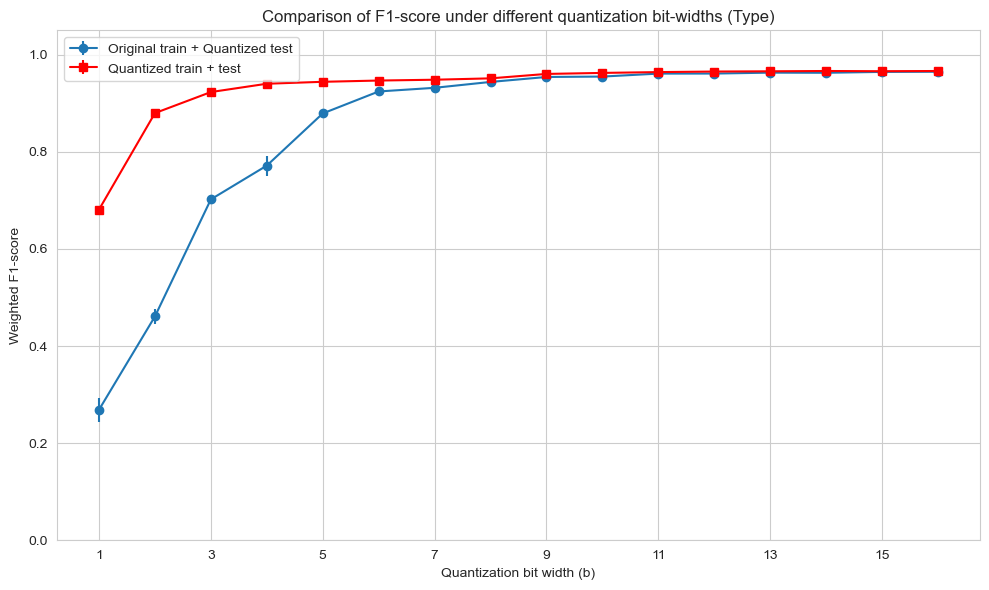

In [13]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

# Define functions for filtering small categories
def filter_small_classes(data, min_samples=15):
    class_counts = data["Device Name"].value_counts()
    classes_to_keep = class_counts[class_counts >= min_samples].index.tolist()
    filtered_data = data[data["Device Name"].isin(classes_to_keep)].copy()
    print(f"Original number of categories: {len(data['Device Name'].unique())}, Number of categories after screening: {len(classes_to_keep)}")
    print(f"Original sample size: {len(data)}, Number of samples after screening: {len(filtered_data)}")
    return filtered_data

# Setting parameters and file paths
base_dir = os.getcwd()
input_folder = os.path.join(base_dir, "6-Merged_Data", "6-Merged_sequence_data_fix_durations")
quantized_folder = os.path.join(base_dir, "8-Quantized_Data",  "Quantized_values")
file_name = "Topology_A_fix_duration_5s.csv"
original_file_path = os.path.join(input_folder, file_name)
new_file_name = file_name.replace(".csv", "")

os.makedirs(input_folder, exist_ok=True)
os.makedirs(quantized_folder, exist_ok=True)

b_values = list(range(1, 17))
file_paths = {f"b{b}": os.path.join(quantized_folder, f"{new_file_name}_value_b{b}.csv") for b in b_values}
file_paths["Original"] = original_file_path

if not os.path.exists(original_file_path):
    raise FileNotFoundError(f"non-existent: {original_file_path}")

original_data = pd.read_csv(file_paths["Original"])

# original_data = filter_small_classes(original_data, min_samples=15)

categories = original_data["Device Type"].unique()

y_orig = pd.Categorical(original_data["Device Type"], categories=categories).codes
X_orig = original_data.drop(columns=["Device Name", "Device Type", "File Name"])

k_folds = 5
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)


f1_curve1 = {f"b{b}": [] for b in b_values}  # Raw data training, quantitative data testing
f1_curve2 = {f"b{b}": [] for b in b_values}  # Quantitative data training + testing

fold_count = 1
for train_idx, test_idx in kf.split(X_orig, y_orig):
    X_train_orig, X_test_orig = X_orig.iloc[train_idx], X_orig.iloc[test_idx]
    y_train_orig, y_test_orig = np.array(y_orig)[train_idx], np.array(y_orig)[test_idx]

    train_indices = X_orig.index[train_idx]
    test_indices = X_orig.index[test_idx]

    class_weights_orig = compute_class_weight(class_weight="balanced", classes=np.unique(y_train_orig), y=y_train_orig)
    class_weight_dict_orig = {i: weight for i, weight in enumerate(class_weights_orig)}

    rf_orig = RandomForestClassifier(random_state=42, class_weight=class_weight_dict_orig)
    rf_orig.fit(X_train_orig, y_train_orig)

    # Curve 1
    for b in b_values:
        b_key = f"b{b}"
        data = pd.read_csv(file_paths[b_key])
        data = data[data["Device Type"].isin(categories)].copy()

        try:
            X_test = data.drop(columns=["Device Name", "Device Type", "File Name"]).loc[test_indices]
            y_test = pd.Categorical(data.loc[test_indices, "Device Type"], categories=categories).codes

            y_pred = rf_orig.predict(X_test)
            f1 = f1_score(y_test, y_pred, average='weighted')
            f1_curve1[b_key].append(f1)
        except KeyError:
            continue

    # Curve 2
    for b in b_values:
        b_key = f"b{b}"
        data = pd.read_csv(file_paths[b_key])
        data = data[data["Device Type"].isin(categories)].copy()

        try:
            X_train = data.drop(columns=["Device Name", "Device Type", "File Name"]).loc[train_indices]
            y_train = pd.Categorical(data.loc[train_indices, "Device Type"], categories=categories).codes
            X_test = data.drop(columns=["Device Name", "Device Type", "File Name"]).loc[test_indices]
            y_test = pd.Categorical(data.loc[test_indices, "Device Type"], categories=categories).codes

            class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
            class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

            rf = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
            rf.fit(X_train, y_train)

            y_pred = rf.predict(X_test)
            f1 = f1_score(y_test, y_pred, average='weighted')
            f1_curve2[b_key].append(f1)
        except (KeyError, ValueError):
            continue

    fold_count += 1

# Calculation of mean and standard deviation
f1_avg1 = {b_key: np.mean(scores) for b_key, scores in f1_curve1.items() if scores}
f1_std1 = {b_key: np.std(scores) for b_key, scores in f1_curve1.items() if scores}
f1_avg2 = {b_key: np.mean(scores) for b_key, scores in f1_curve2.items() if scores}
f1_std2 = {b_key: np.std(scores) for b_key, scores in f1_curve2.items() if scores}

# output result
print("Raw training + quantitative testing:")
for b in b_values:
    b_key = f"b{b}"
    if b_key in f1_avg1:
        print(f"b={b}: {f1_avg1[b_key]:.4f} ± {f1_std1[b_key]:.4f}")

print("\nQuantitative training + Quantitative testing：")
for b in b_values:
    b_key = f"b{b}"
    if b_key in f1_avg2:
        print(f"b={b}: {f1_avg2[b_key]:.4f} ± {f1_std2[b_key]:.4f}")

plt.figure(figsize=(10, 6))
plt.errorbar(b_values, [f1_avg1[f"b{b}"] if f"b{b}" in f1_avg1 else 0 for b in b_values],
             yerr=[f1_std1[f"b{b}"] if f"b{b}" in f1_std1 else 0 for b in b_values],
             label="Original train + Quantized test", fmt='-o')
plt.errorbar(b_values, [f1_avg2[f"b{b}"] if f"b{b}" in f1_avg2 else 0 for b in b_values],
             yerr=[f1_std2[f"b{b}"] if f"b{b}" in f1_std2 else 0 for b in b_values],
             label="Quantized train + test", fmt='-s',color = "r")
plt.xlabel("Quantization bit width (b)")
plt.ylabel("Weighted F1-score")
plt.title("Comparison of F1-score under different quantization bit-widths (Type)")
plt.xticks(b_values[::2])
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.tight_layout()
# Save the figure
result_dir = os.path.join(base_dir, "9-different b Results")
os.makedirs(result_dir, exist_ok=True)
plt.savefig(os.path.join(result_dir, "quantization_f1_comparison_filtered_Type.png"))
plt.show()


## Name classification

Original number of categories: 20, Number of categories after screening: 14
Original sample size: 21081, Number of samples after screening: 21050
Raw training + quantitative testing:
b=1: 0.2398 ± 0.0005
b=2: 0.3265 ± 0.0077
b=3: 0.4221 ± 0.0242
b=4: 0.5938 ± 0.0059
b=5: 0.7064 ± 0.0069
b=6: 0.7844 ± 0.0068
b=7: 0.8207 ± 0.0072
b=8: 0.8604 ± 0.0058
b=9: 0.8811 ± 0.0055
b=10: 0.8951 ± 0.0047
b=11: 0.9091 ± 0.0035
b=12: 0.9135 ± 0.0046
b=13: 0.9219 ± 0.0047
b=14: 0.9248 ± 0.0036
b=15: 0.9279 ± 0.0036
b=16: 0.9306 ± 0.0036

Quantitative training + Quantitative testing：
b=1: 0.5069 ± 0.0058
b=2: 0.7178 ± 0.0041
b=3: 0.7752 ± 0.0035
b=4: 0.8266 ± 0.0030
b=5: 0.8394 ± 0.0024
b=6: 0.8586 ± 0.0043
b=7: 0.8764 ± 0.0057
b=8: 0.8889 ± 0.0047
b=9: 0.9028 ± 0.0029
b=10: 0.9108 ± 0.0012
b=11: 0.9182 ± 0.0028
b=12: 0.9226 ± 0.0026
b=13: 0.9252 ± 0.0037
b=14: 0.9281 ± 0.0031
b=15: 0.9308 ± 0.0038
b=16: 0.9320 ± 0.0039


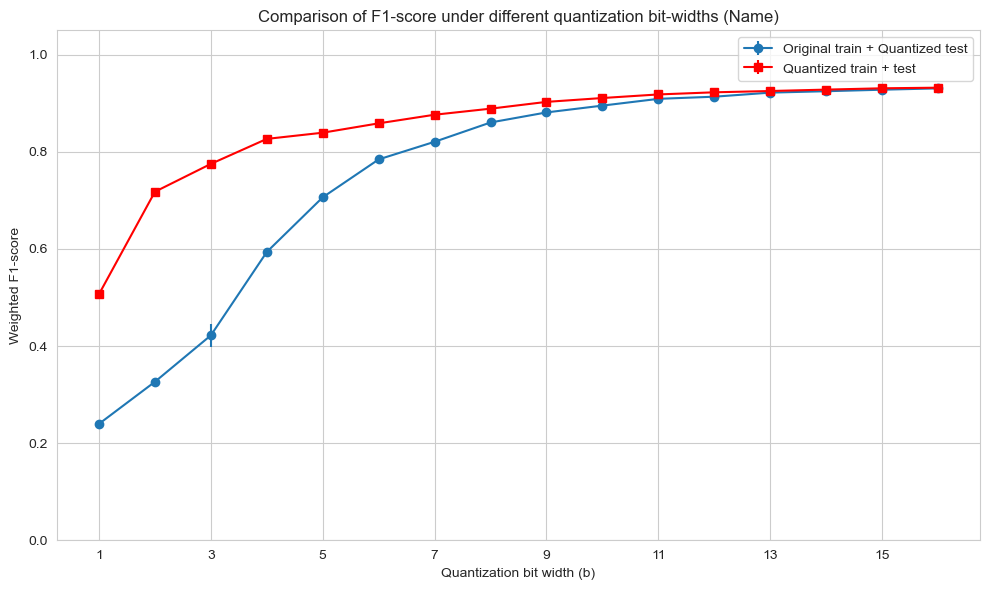

In [14]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

# 定义筛选小类别的函数
def filter_small_classes(data, min_samples=15):
    class_counts = data["Device Name"].value_counts()
    classes_to_keep = class_counts[class_counts >= min_samples].index.tolist()
    filtered_data = data[data["Device Name"].isin(classes_to_keep)].copy()
    print(f"Original number of categories: {len(data['Device Name'].unique())}, Number of categories after screening: {len(classes_to_keep)}")
    print(f"Original sample size: {len(data)}, Number of samples after screening: {len(filtered_data)}")
    return filtered_data


base_dir = os.getcwd()
input_folder = os.path.join(base_dir, "6-Merged_Data", "6-Merged_sequence_data_fix_durations")
quantized_folder = os.path.join(base_dir, "8-Quantized_Data",  "Quantized_values")
file_name = "Topology_A_fix_duration_5s.csv"
original_file_path = os.path.join(input_folder, file_name)
new_file_name = file_name.replace(".csv", "")


os.makedirs(input_folder, exist_ok=True)
os.makedirs(quantized_folder, exist_ok=True)


b_values = list(range(1, 17))
file_paths = {f"b{b}": os.path.join(quantized_folder, f"{new_file_name}_value_b{b}.csv") for b in b_values}
file_paths["Original"] = original_file_path


if not os.path.exists(original_file_path):
    raise FileNotFoundError(f"non-existence: {original_file_path}")


original_data = pd.read_csv(file_paths["Original"])


original_data = filter_small_classes(original_data, min_samples=15)


categories = original_data["Device Name"].unique()


y_orig = pd.Categorical(original_data["Device Name"], categories=categories).codes
X_orig = original_data.drop(columns=["Device Name", "Device Type", "File Name"])


k_folds = 5
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)


f1_curve1 = {f"b{b}": [] for b in b_values}  # Raw data training, quantitative data testing
f1_curve2 = {f"b{b}": [] for b in b_values}  # Quantitative data training + testing


fold_count = 1
for train_idx, test_idx in kf.split(X_orig, y_orig):

    X_train_orig, X_test_orig = X_orig.iloc[train_idx], X_orig.iloc[test_idx]
    y_train_orig, y_test_orig = np.array(y_orig)[train_idx], np.array(y_orig)[test_idx]


    train_indices = X_orig.index[train_idx]
    test_indices = X_orig.index[test_idx]


    class_weights_orig = compute_class_weight(class_weight="balanced", classes=np.unique(y_train_orig), y=y_train_orig)
    class_weight_dict_orig = {i: weight for i, weight in enumerate(class_weights_orig)}

    rf_orig = RandomForestClassifier(random_state=42, class_weight=class_weight_dict_orig)
    rf_orig.fit(X_train_orig, y_train_orig)

    # Curve 1：
    for b in b_values:
        b_key = f"b{b}"
        data = pd.read_csv(file_paths[b_key])
        data = data[data["Device Name"].isin(categories)].copy()

        try:
            X_test = data.drop(columns=["Device Name", "Device Type", "File Name"]).loc[test_indices]
            y_test = pd.Categorical(data.loc[test_indices, "Device Name"], categories=categories).codes

            y_pred = rf_orig.predict(X_test)
            f1 = f1_score(y_test, y_pred, average='weighted')
            f1_curve1[b_key].append(f1)
        except KeyError:
            continue

    # curve 2：
    for b in b_values:
        b_key = f"b{b}"
        data = pd.read_csv(file_paths[b_key])
        data = data[data["Device Name"].isin(categories)].copy()

        try:
            X_train = data.drop(columns=["Device Name", "Device Type", "File Name"]).loc[train_indices]
            y_train = pd.Categorical(data.loc[train_indices, "Device Name"], categories=categories).codes
            X_test = data.drop(columns=["Device Name", "Device Type", "File Name"]).loc[test_indices]
            y_test = pd.Categorical(data.loc[test_indices, "Device Name"], categories=categories).codes

            class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
            class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

            rf = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
            rf.fit(X_train, y_train)

            y_pred = rf.predict(X_test)
            f1 = f1_score(y_test, y_pred, average='weighted')
            f1_curve2[b_key].append(f1)
        except (KeyError, ValueError):
            continue

    fold_count += 1

# Calculation of mean and standard deviation
f1_avg1 = {b_key: np.mean(scores) for b_key, scores in f1_curve1.items() if scores}
f1_std1 = {b_key: np.std(scores) for b_key, scores in f1_curve1.items() if scores}
f1_avg2 = {b_key: np.mean(scores) for b_key, scores in f1_curve2.items() if scores}
f1_std2 = {b_key: np.std(scores) for b_key, scores in f1_curve2.items() if scores}

# output result
print("Raw training + quantitative testing:")
for b in b_values:
    b_key = f"b{b}"
    if b_key in f1_avg1:
        print(f"b={b}: {f1_avg1[b_key]:.4f} ± {f1_std1[b_key]:.4f}")

print("\nQuantitative training + Quantitative testing：")
for b in b_values:
    b_key = f"b{b}"
    if b_key in f1_avg2:
        print(f"b={b}: {f1_avg2[b_key]:.4f} ± {f1_std2[b_key]:.4f}")

# Plotting the results
plt.figure(figsize=(10, 6))
plt.errorbar(b_values, [f1_avg1[f"b{b}"] if f"b{b}" in f1_avg1 else 0 for b in b_values],
             yerr=[f1_std1[f"b{b}"] if f"b{b}" in f1_std1 else 0 for b in b_values],
             label="Original train + Quantized test", fmt='-o')
plt.errorbar(b_values, [f1_avg2[f"b{b}"] if f"b{b}" in f1_avg2 else 0 for b in b_values],
             yerr=[f1_std2[f"b{b}"] if f"b{b}" in f1_std2 else 0 for b in b_values],
             label="Quantized train + test", fmt='-s',color = "r")
plt.xlabel("Quantization bit width (b)")
plt.ylabel("Weighted F1-score")
plt.title("Comparison of F1-score under different quantization bit-widths (Name)")
plt.xticks(b_values[::2])
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.tight_layout()

# Save the figure
result_dir = os.path.join(base_dir, "9-different b Results")
os.makedirs(result_dir, exist_ok=True)
plt.savefig(os.path.join(result_dir, "quantization_f1_comparison_filtered_Name.png"))
plt.show()
